In [2]:
import jax
import jax.numpy as jnp
from flax import linen as nn
import flax.serialization as ser
import os

import matplotlib.pyplot as plt
import optax
import copy

import itertools

In [3]:
# Number of Sensors
n_s = 40

#fixed parameters for the
delta_theta = 0.2


v0 = 10.0
dv = 2.0
tau = 4
opacity_threshold = 0.5

dt = 1


epsilon = 0.1

sensor_bounds = jnp.array([2*jnp.pi/n_s * i for i in range(n_s+1)])  # length N+1

velocity = jnp.array([v0,v0,v0,v0+dv,v0-dv])
orientation = jnp.array([delta_theta, 0.0, -delta_theta, 0.0, 0.0])


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [4]:
num_actions = 5


class QNetwork(nn.Module):
    num_actions: int = 5

    @nn.compact
    def __call__(self, x):
        x = nn.Dense(128)(x)
        x = nn.relu(x)
        x = nn.Dense(128)(x)
        x = nn.relu(x)
        x = nn.Dense(128)(x)
        x = nn.relu(x)
        x = nn.Dense(self.num_actions)(x)   # Linear output
        return x
    
def q_values(params, states):
    """
    params: network parameters (online or target)
    states: array of shape (batch, n_s)
    returns: Q-values of shape (batch, num_actions)
    """
    return q_model.apply(params, states)

def compute_td_target(target_params, rewards, next_states, gamma=0.99):
    """
    target_params: parameters of the target network
    rewards: shape (batch,)
    next_states: shape (batch, 30)
    dones: shape (batch,) with 1 if episode ended, else 0
    gamma: discount factor
    """

    # Q-values from the target network for the next states
    q_next = q_values(target_params, next_states)   # shape: (batch, 5)

    # max_a Q(s', a')
    max_next_q = jnp.max(q_next, axis=1)           # shape: (batch,)

    # TD target:
    #   r + gamma * max_next_q * (1 - done)
    target = rewards + gamma * max_next_q

    return target

@jax.jit
def train_step(online_params, target_params, opt_state,
               states, actions, rewards, next_states):
    """
    Performs one gradient update on the online Q-network.
    """

    # Define loss function inside so JAX can compute gradients
    def loss_fn(params):
        # 1. Q-values from online network for current states
        q_all = q_values(params, states)    # shape: (batch, 5)

        # 2. Select Q-value for the action taken
        # actions is shape (batch,), so we gather the correct column
        q_pred = jnp.take_along_axis(
            q_all, actions[:, None], axis=1
        ).squeeze()                          # shape: (batch,)

        # 3. Compute TD target using the target network
        td_target = compute_td_target(
            target_params, rewards, next_states
        )

        # 4. MSE loss
        loss = jnp.mean((q_pred - td_target) ** 2)

        return loss

    # 5. Compute gradients
    loss, grads = jax.value_and_grad(loss_fn)(online_params)

    # 6. Apply optimizer update
    updates, opt_state = optimizer.update(grads, opt_state, online_params)
    new_online_params = optax.apply_updates(online_params, updates)

    # 7. Return everything updated
    return new_online_params, opt_state, loss

def iterate_minibatches(states, actions, rewards, next_states, batch_size, rng):
    """
    Simple generator that yields mini-batches from the full dataset.
    All inputs are jnp.arrays with the same length N in axis 0.
    """
    N = states.shape[0]

    # Create a random permutation of indices to shuffle the data
    perm = jax.random.permutation(rng, N)
    perm = jnp.array(perm)

    # Apply the permutation to shuffle all arrays in the same way
    states_shuffled      = states[perm]
    actions_shuffled     = actions[perm]
    rewards_shuffled     = rewards[perm]
    next_states_shuffled = next_states[perm]

    # Step through the shuffled data in chunks of batch_size
    for start in range(0, N, batch_size):
        end = start + batch_size
        if end > N:
            break  # drop last incomplete batch for simplicity

        yield (
            states_shuffled[start:end],
            actions_shuffled[start:end],
            rewards_shuffled[start:end],
            next_states_shuffled[start:end],
        )

        
def train_one_epoch(online_params, target_params, opt_state,
                    states, actions, rewards, next_states,
                    batch_size, epoch_rng):
    """
    Trains online_params for one full epoch over the entire offline dataset.
    Returns updated (online_params, opt_state) and the final loss observed.
    """

    last_loss = 0.0

    # Generate minibatches using the epoch-specific RNG
    for (batch_states, batch_actions, batch_rewards, batch_next_states) in \
        iterate_minibatches(states, actions, rewards, next_states, batch_size, epoch_rng):

        # Perform one update on this minibatch
        online_params, opt_state, loss = train_step(
            online_params,
            target_params,
            opt_state,
            batch_states,
            batch_actions,
            batch_rewards,
            batch_next_states
        )

        last_loss = loss  # store last loss (optional)

    return online_params, opt_state, last_loss

def train_for_epochs(
    online_params,
    target_params,
    opt_state,
    states,
    actions,
    rewards,
    next_states,
    batch_size=80,
    num_epochs=10):
    """
    Train the online network for num_epochs over the offline dataset.
    Returns: updated online_params, opt_state
    """
    rng = jax.random.PRNGKey(0)  # master seed for epoch shuffles
    losses = []

    for epoch in range(num_epochs):
        # Create a unique RNG key for each epoch
        rng, epoch_rng = jax.random.split(rng)

        # Train one epoch
        online_params, opt_state, last_loss = train_one_epoch(
            online_params,
            target_params,
            opt_state,
            states,
            actions,
            rewards,
            next_states,
            batch_size,
            epoch_rng
        )
        
        losses.append(float(last_loss))
        
        print(f"Epoch {epoch+1}/{num_epochs}, loss = {float(last_loss):.6f}")

    return online_params, opt_state, losses

def update_target_network(online_params):
    """
    Hard update: make target network equal to the new online network.
    """
    return copy.deepcopy(online_params)



In [5]:
def init(key, N = 1):
    # Split RNG for reproducibility
    key1, key2, key3, key4 = jax.random.split(key, num = 4)
    
    size = jax.random.uniform(key4)
    
    # Positions: uniform in [0,1) scaled by N
    x_positions = jax.random.uniform(key1, (N,)) * 2 * N * size 

    y_positions = jax.random.uniform(key2, (N,)) * 2 * N * size 

    # Orientations: normal with mean 0, std=1, scaled by delta_theta
    orientations = jax.random.normal(key3, (N,)) * delta_theta
    
    velocities = jnp.full((N,), v0)
    
    return x_positions, y_positions, orientations, velocities

def apply_action(x, y, o, action):
    
    o_next = o + orientation[action]
        # Update position
        
    x_next = x + velocity[action] * jnp.cos(o_next) * dt
    y_next = y + velocity[action] * jnp.sin(o_next) * dt
    v_next = velocity[action]
    
    return x_next, y_next, o_next, v_next


def simulate_path(path, agent_state, assumed_positions, velocity, orientation):
            
    x_i, y_i, o_i = agent_state
    
#     jax.debug.print("{}", assumed_positions[0,:])
    

    def step_fn(carry, depth):

        x, y, o, collision_flag = carry
        
        action = path[depth]
        
        x_next, y_next, o_next, v_next = apply_action(x, y, o, action)
        
        # Compute whether a collision occurs at this step
        collision_now = check_collision(x,y, x_next, y_next, assumed_positions[depth, :], assumed_positions[depth+1, :], o_next)
        
        # Update cumulative collision flag (once collision, always collision)
        collision_flag_next = jnp.maximum(collision_flag, collision_now)
        
        vs = get_visual_state(x_next, y_next, o_next, assumed_positions[depth+1, :])
        
        new_carry = (x_next, y_next, o_next, collision_flag_next)
        metrics = (vs, collision_flag_next)
        return new_carry, metrics

    init_carry = (x_i, y_i, o_i, 0)
    _, metrics = jax.lax.scan(step_fn, init_carry, jnp.arange(tau))
    
    
    vs_trajectory, collision_trajectory = metrics
    
    return vs_trajectory, collision_trajectory[-1]

def check_collision(x_old, y_old, x_new, y_new, assumed_positions_old, assumed_positions_new, o_next, threshold=2.0):

    """
    Calculate whether there is a collision between actions
    """
    rx_new = assumed_positions_new[:, 0] - x_new
    ry_new = assumed_positions_new[:, 1] - y_new
    
    rx_old = assumed_positions_old[:, 0] - x_old
    ry_old = assumed_positions_old[:, 1] - y_old
    
    dx, dy   = (rx_old - rx_new), (ry_old - ry_new)  # segment direction toward "old"
    
    dd   = dx * dx + dy * dy
    
    r0d  = rx_new * dx + ry_new * dy

    eps  = 1e-12
    safe = dd > eps
    t_star = jnp.where(safe, -r0d / dd, 0.5)  # dummy where degenerate, will be masked out

    strictly_between = (t_star > 0.0) & (t_star < 1.0) & safe
    
    cx = rx_new + t_star * dx
    cy = ry_new + t_star * dy
    c2 = cx * cx + cy * cy
    interior_close = strictly_between & (c2 <= threshold * threshold)
    
    return jnp.any(interior_close)
    
def rotate_vectors(vectors, theta):
    # rotation matrix for clockwise rotation by theta
    
#     jax.debug.print("{}", vectors)
    
    rot = jnp.array([
        [jnp.cos(theta), jnp.sin(theta)],
        [-jnp.sin(theta),jnp.cos(theta)]
    ])
    return vectors @ rot.T  
    
def binary_array_to_number(binary_array):

    N = binary_array.shape[0]
    powers_of_two = 2 ** jnp.arange(N-1, -1, -1)
    return jnp.sum(binary_array * powers_of_two)

def _split_generator():

    def fun(arc):
        return jax.lax.cond(
            arc[1] > 2 * jnp.pi,
            lambda: [
                jnp.array([arc[0], 2*jnp.pi]),
                jnp.array([jnp.zeros_like(2*jnp.pi), arc[1]%(2*jnp.pi)]),
            ],
            lambda: [jnp.array(arc), jnp.array([2*jnp.pi,2*jnp.pi])],
        )

    return fun

_split = jax.vmap(_split_generator(), in_axes=0)
    
def unionise_projection(arcs):
    
    def scan_fn(carry, idx):
        i, mergearcs = carry
        a = arcs[idx]

        # check overlap: current arc start <= previous merged arc end
        overlap = a[0] <= mergearcs[i, 1]

        def merge_fn(_):
            # merge current arc into previous
            new_mergearcs = mergearcs.at[i, 1].set(jnp.maximum(mergearcs[i, 1], a[1]))
            return i, new_mergearcs

        def next_fn(_):
            # move to next merged arc
            new_mergearcs = mergearcs.at[i + 1].set(a)
            return i + 1, new_mergearcs

        new_carry = jax.lax.cond(overlap, merge_fn, next_fn, operand=None)
        return new_carry, None

    # initialize merged arcs array
    arcs = arcs[jnp.argsort(arcs[:, 0])]  # sort on end angle
    mergearcs = jnp.zeros_like(arcs)
    mergearcs = mergearcs.at[0].set(arcs[0])
    init_carry = (0, mergearcs)

    # scan over remaining arcs
    (i, mergearcs), _ = jax.lax.scan(scan_fn, init_carry, jnp.arange(1, arcs.shape[0]))
    return i, mergearcs

def sensor_fill(sensor_range, intervals):
    """
    Compute how much of a single sensor range is covered by intervals.
    """
    s0, s1 = sensor_range
    l, r = intervals[:,0], intervals[:,1]
    overlaps = jnp.maximum(0.0, jnp.minimum(r, s1) - jnp.maximum(l, s0))
    return jnp.sum(overlaps)

def fill_sensors(sensor_bounds, merged_intervals):
    sensor_ranges = jnp.stack([sensor_bounds[:-1], sensor_bounds[1:]], axis=1)    
    fill_per_sensor = jax.vmap(sensor_fill, in_axes=(0,None))(sensor_ranges, merged_intervals)
    sensor_sizes = sensor_bounds[1:] - sensor_bounds[:-1]
    fill_fraction = fill_per_sensor / sensor_sizes
    return jnp.where(fill_fraction > opacity_threshold , 1, 0)
        
simulate_paths_vmap = jax.vmap(simulate_path, in_axes=(0, None, None, None, None))

def argmax_random_tie(q_values, key):
    """
    q_values: shape (..., A)
    key: PRNGKey
    returns: indices of shape (...) with random tie-breaking over argmax
    """
    # 1. max per row / vector
    max_q = jnp.max(q_values, axis=-1, keepdims=True)

    # 2. mask of max positions
    is_max = (q_values == max_q)

    # 3. random noise for every entry
    noise = jax.random.uniform(key, shape=q_values.shape)

    # 4. keep noise only on max entries, zero elsewhere
    #    (non-max entries are exactly 0; max entries are in (0,1))
    scores = jnp.where(is_max, noise, 0.0)

    # 5. argmax over the (possibly batched) last dimension
    return jnp.argmax(scores, axis=-1)

def epsilon_greedy(q_values, key, epsilon):
    num_actions = q_values.shape[-1]

    key, greedy_key, random_key, eps_key = jax.random.split(key, 4)

    greedy_act = argmax_random_tie(q_values, greedy_key)
    random_act = jax.random.randint(random_key, shape=(), minval=0, maxval=num_actions)
    take_random = jax.random.uniform(eps_key) < epsilon

    return jnp.where(take_random, random_act, greedy_act)

def heuristic_positions(x, y, o, prev_vis_states, tau, QNN_params, key):
    """
    Takes the current positions of all the agents.
    Assumes each agent is using the QNN to decide the action.
    QNN takes the visual state from the x,y,o at t
    
    """
    state0 = (key, x, y, o, prev_vis_states)

    def rollout_step(state, _):
        key, x, y, o, prev_vis_states = state
        
        key, subkey = jax.random.split(key)
        
        # 1) visual states for all agents
        vis_state_integers = jnp.array(compute_visual_states(x, y, o))   # (N,)
        curr_vis_states = jax.vmap(lambda n: to_binary(n, n_s))(vis_state_integers)
        
        # use the memory to produce the input for the NN
        batched_get_input = jax.vmap(get_input_state, in_axes=(0,0))
        states = batched_get_input(prev_vis_states, curr_vis_states)
        
        # 2) Q-values for each agent
        agents_q_values = jax.vmap(q_values, in_axes=(None, 0))(QNN_params, states)
    
        # 3) greedy actions (no epsilon here)
        
        actions = argmax_random_tie(agents_q_values, subkey) 
        # 4) environment dynamics
        x_next, y_next, o_next, v_next = apply_action(
            x, y, o, actions)  # each (N,)
    
        # 5) positions at this next step
        positions_next = jnp.stack([x_next, y_next], axis=-1)    # (N, 2)

        next_state = (key, x_next, y_next, o_next, curr_vis_states)
        return next_state, positions_next  # carry, y

    # run tau steps forward
    _, future_positions = jax.lax.scan(
        rollout_step,
        state0,
        jnp.arange(tau)       # just a dummy index
    )  # future_positions: (tau, N, 2) for steps 1..tau

    # current positions as time t=0
    current_positions = jnp.stack([x, y], axis=-1)[None, ...]   # (1, N, 2)

    # concat to get (tau+1, N, 2): [t=0] + [t=1..tau]
    assumed_positions = jnp.concatenate(
        [current_positions, future_positions],
        axis=0
    )

    return assumed_positions

def run_sim(key, N, T, QNN_params):
    """
    Runs one simulation of N agents for T Time
    QNN: The network used for the heuristic
    """
    # set up the agents
    x0, y0, o0, v0 = init(key, N)
        
    init_vis_states = jnp.zeros((N, n_s), dtype=jnp.int32)
    carry0 = (key, x0, y0, o0, v0, init_vis_states, QNN_params)
    
    def step(carry, t):
        key, x, y, o, v, prev_vis_states, params = carry
        
        key, subkey, key_heuristic = jax.random.split(key, 3)

        # get current visual states
        vis_state_integers = jnp.array(compute_visual_states(x, y, o))   # (N,)
        curr_vis_states = jax.vmap(lambda n: to_binary(n, n_s))(vis_state_integers)
                    
        # use the memory to produce the input for the NN
        batched_get_input = jax.vmap(get_input_state, in_axes=(0,0))
        states = batched_get_input(prev_vis_states, curr_vis_states)

        # epsilon-greedy pick an action
        
        # 2) Q-values for each agent
        agents_q_values = jax.vmap(q_values, in_axes=(None, 0))(QNN_params, states)

        agent_keys = jax.random.split(subkey, N)   # N keys

        def select_action(qv, k):
            return epsilon_greedy(qv, k, epsilon)

        actions = jax.vmap(select_action)(agents_q_values, agent_keys)    # (N,)
        
#         actions = jnp.array([0 for i in range(5)])
        
        assumed_positions = heuristic_positions(x, y, o, prev_vis_states, tau, QNN_params, key_heuristic)  # shape (tau + 1, N, 2)
        
        def agent_fn(i):
        # roll agents so this agent is first
            x_roll, y_roll, o_roll = jnp.roll(x, -i), jnp.roll(y, -i), jnp.roll(o, -i)
            assumed_roll = jnp.roll(assumed_positions, -i, axis=1)

            agent_state = (x_roll[0], y_roll[0], o_roll[0])
            
            paths = possible_paths(jnp.roll(actions,-i)[0], num_actions, tau)

            vs = simulate_paths_vmap(paths, agent_state, assumed_roll[:, 1:], velocity, orientation)
            
            #calculate entropy from visual states
            e = entropy(vs[0],vs[1])

            return e       

        rewards = jax.vmap(agent_fn)(jnp.arange(N))  # (N,)
                                
        # update positions
        x1, y1, o1, v1 = apply_action(x, y, o, actions)
        
        next_vis_integers = compute_visual_states(x1, y1, o1)
        next_vis_states = jax.vmap(lambda n: to_binary(n, n_s))(next_vis_integers)

        transition = (curr_vis_states, actions, rewards, next_vis_states, x1, y1, o1, v1)

        new_carry = (key, x1, y1, o1, v1, curr_vis_states, params)
        
        return new_carry, transition
    
    carry_final, transitions = jax.lax.scan(step, carry0,jnp.arange(T),)
        
    return transitions   # see shapes below


def run_NN(key, N, T, QNN_params):
    """
    Runs one simulation of N agents for T Time
    QNN: The network used for the heuristic
    """
    # set up the agents
    x0, y0, o0, v0 = init(key, N)
        
    init_vis_states = jnp.zeros((N, n_s), dtype=jnp.int32)
    carry0 = (key, x0, y0, o0, v0, init_vis_states, QNN_params)
    
    def step(carry, t):
        key, x, y, o, v, prev_vis_states, params = carry
        
        key, subkey = jax.random.split(key)

        # get current visual states
        vis_state_integers = jnp.array(compute_visual_states(x, y, o))   # (N,)
        curr_vis_states = jax.vmap(lambda n: to_binary(n, n_s))(vis_state_integers)
                    
        # use the memory to produce the input for the NN
        batched_get_input = jax.vmap(get_input_state, in_axes=(0,0))
        states = batched_get_input(prev_vis_states, curr_vis_states)
       
        # 2) Q-values for each agent
        agents_q_values = jax.vmap(q_values, in_axes=(None, 0))(QNN_params, states)

        actions = argmax_random_tie(agents_q_values, subkey) 
        
#         actions = jnp.array([0 for i in range(5)])
                                        
        # update positions
        x1, y1, o1, v1 = apply_action(x, y, o, actions)
        
        next_vis_integers = compute_visual_states(x1, y1, o1)
        next_vis_states = jax.vmap(lambda n: to_binary(n, n_s))(next_vis_integers)

        transition = (x1, y1, o1, v1)

        new_carry = (key, x1, y1, o1, v1, curr_vis_states, params)
        
        return new_carry, transition
    
    carry_final, transitions = jax.lax.scan(step, carry0,jnp.arange(T),)
        
    return transitions   # see shapes below


def entropy(visual_states, collision_flags):

    mask = (collision_flags == 0)[:, None, None]    # (num_paths, 1, 1)
    
    masked_vs = jnp.where(mask, visual_states, -1) # still (num_paths, K, D)

    flat = masked_vs.ravel()
    
    uniques, counts = jnp.unique(
        flat, return_counts=True, size= len(flat), fill_value=-1)

    valid = uniques != -1

    counts = jnp.where(valid, counts, 0)
    
    total = counts.sum()
    total = jnp.maximum(total, 1)  # avoid divide-by-zero
    probs = counts.astype(jnp.float32) / total

    nonzero = counts > 0
    probs_safe = jnp.where(nonzero, probs, 1.0)  # log(1)=0 for masked
    e = -jnp.sum(jnp.where(nonzero, probs * jnp.log(probs_safe), 0.0))
    
    return e

def possible_paths(first_action, num_actions, tau):
    """
    first_action : scalar int, in [0, num_actions)
    num_actions  : total available discrete actions
    tau          : length of each path

    Returns
    -------
    paths : (num_paths, tau) int32
        All possible action sequences of length `tau`,
        with paths[:, 0] == first_action.
    """
    if tau == 1:
        # Only one step: just the already chosen action
        return jnp.array([[first_action]], dtype=jnp.int32)

    # Shape for the remaining tau-1 steps: (num_actions, num_actions, ..., num_actions)
    # length of this tuple is tau-1
    grid_shape = (num_actions,) * (tau - 1)

    # jnp.indices(grid_shape) has shape (tau-1, num_actions, ..., num_actions)
    # Each "row" along axis 0 represents the values along one time index.
    grid = jnp.indices(grid_shape)  # (tau-1, num_actions, ..., num_actions)

    # Flatten all the combination dimensions into one axis
    # grid.reshape(tau-1, -1) has shape (tau-1, num_paths)
    rest_actions = grid.reshape(tau - 1, -1).transpose(1, 0)  # (num_paths, tau-1)

    num_paths = rest_actions.shape[0]

    # Column of the fixed first_action, shape (num_paths, 1)
    first_col = jnp.full((num_paths, 1), first_action, dtype=jnp.int32)

    # Concatenate to get full paths: (num_paths, tau)
    paths = jnp.concatenate([first_col, rest_actions], axis=1)

    return paths



In [6]:
def compute_visual_states(x, y, o):
    current_positions = jnp.stack([x, y], axis=-1)    # (N, 2)
    
    def agent_fn(i):
#         #roll agents so this agent is first
        x_roll, y_roll, o_roll = jnp.roll(x, -i), jnp.roll(y, -i), jnp.roll(o, -i)
        current_roll = jnp.roll(current_positions, -i, axis=1)

        agent_state = (x_roll[0], y_roll[0], o_roll[0])
#         jax.debug.print("{}", current_roll[1:])

        vs = get_visual_state(x_roll[0], y_roll[0], o_roll[0], current_roll[1:])
        
        return vs

    return jax.vmap(agent_fn)(jnp.arange(x.shape[0]))
    
    
def get_visual_state(x, y, o, assumed_positions):
    
    rotated = rotate_vectors(assumed_positions - jnp.array([x,y]), o)

    dists = jnp.sqrt(jnp.sum(rotated**2, axis=1))
    
    alphas = jnp.arctan2(rotated[:,1], rotated[:,0])
    
    delta_alpha = jnp.arcsin(1/dists)
    
    delta_alpha = jnp.nan_to_num(delta_alpha, nan= jnp.pi)

    intervals = merged_intervals(alphas, delta_alpha)
    
    sensor = fill_sensors(sensor_bounds, intervals)
    
#     jax.debug.print ("{}", sensor)
    
    return binary_array_to_number(sensor)

def merged_intervals(alphas, delta_alpha):

    left  = (alphas - delta_alpha) % (2 * jnp.pi)
    right = left + 2 * delta_alpha
        
    arcs = jnp.stack([left, right], axis=1)
    
#     jax.debug.print("{}", arcs)
    
    arcs = jnp.concatenate(_split(arcs))
#     jax.debug.print("{}", arcs)

    i, merged_arcs = unionise_projection(arcs)
    
#     jax.debug.print("{}", merged_arcs)
    return merged_arcs

In [7]:
def plot_trajectory(x,y):
    plt.axes().set_aspect('equal')

    plt.plot(x,y, '-')

    plt.show()

def produce_frames(xs,ys, os, vs):
    xvs = [vs[i] * jnp.cos(o) for i,o in enumerate(os)]
    yvs = [vs[i] * jnp.sin(o) for i,o in enumerate(os)]
    for t in range(tMax):
        fig, ax = plt.subplots()


        ax.quiver(xs[t,:], ys[t,:], xvs[t], yvs[t], color = 'k')
        
        for j in range(N):
            circle = plt.Circle((xs[t, j], ys[t, j]), 1.0,
                                color='blue', fill=False, linewidth=1.5)
            ax.add_patch(circle)

            
        plt.gca().set_aspect('equal')

#         ax.set_xlim(xs[t,0] - 2*N, xs[t,0] +  2*N )
#         ax.set_ylim(ys[t,0] - 2*N, ys[t,0] +  2*N )

#         plt.axis('off')

        plt.savefig("VideoPhotos/img" + "%03d" % t + ".jpg")

        plt.close()
    


In [8]:
def to_binary(n, width):
    # Make exponents: [width-1, ..., 1, 0]
    exponents = jnp.arange(width - 1, -1, -1)
    # Compute: (n >> k) & 1 for each bit
    return (n >> exponents) & 1

def mirror_state(state):    
    mirror_state = state[::-1]
    return mirror_state

def mirror_action(action):
    if action == 0:
        return 2
    elif action == 2:
        return 0
    else:
        return action


In [9]:
def get_input_state(prev_vis_state, curr_vis_state):
    return jnp.concatenate([prev_vis_state, curr_vis_state])

def calculate_order(orientations, T = 1):
    x = 0
    y = 0
    N = len(orientations[-1])
    
    for i in range(N):
        for j in range(T):
            x += jnp.cos(orientations[-j-1][i])
            y += jnp.sin(orientations[-j-1][i])
            
    order = jnp.sqrt(x*x + y*y)/(N*T)
    return order

def prepare_data(data):
    states = []
    actions = []
    rewards = []
    next_states = []
    
    for i in range(N):
        for j in range(1,T):
            prev_vis_state = data[0][j][i-1]
            curr_vis_state = data[0][j][i]
            action = data[1][j][i]
            reward = data[2][j][i]
            next_vis_state = data[3][j][i]
            
            state = get_input_state(prev_vis_state, curr_vis_state)
            next_state = get_input_state(curr_vis_state, next_vis_state)
            states.append(state)
            actions.append(action)
            rewards.append(reward)
            next_states.append(next_state)
            
            mirrored_state = get_input_state(mirror_state(prev_vis_state), mirror_state(curr_vis_state))
            mirrored_next_state = get_input_state(mirror_state(curr_vis_state), mirror_state(next_vis_state))
            
            states.append(mirrored_state)
            actions.append(mirror_action(action))
            rewards.append(reward)
            next_states.append(mirrored_next_state)
    
    states = jnp.array(states)
    actions = jnp.array(actions)
    rewards = jnp.array(rewards)
    next_states = jnp.array(next_states)

    return states, actions, rewards, next_states


def evaluate_NN(key, sims, params):
    orders = 0
    for i in range(sims):
        key, subkey = jax.random.split(key) 

        data = run_NN(subkey, N, T, params)

        orders += calculate_order(data[2])
    return orders/sims

def save_checkpoint(path, online_params, target_params, opt_state, cycle):
    data = {
        "cycle": cycle,
        "online_params": online_params,
        "target_params": target_params,
        "opt_state": opt_state,
    }
    bytes_data = ser.to_bytes(data)

    path = f"{save_dir}/cycle_{cycle}.ckpt"
    with open(path, "wb") as f:
        f.write(bytes_data)

    print(f"Saved checkpoint at {path}")
        
save_dir = "./Checkpoints"
os.makedirs(save_dir, exist_ok=True)
        
def load_checkpoint(path):
    with open(path, "rb") as f:
        bytes_data = f.read()
    return ser.from_bytes(None, bytes_data)

    


In [10]:
N = 20
T = 500
key = jax.random.PRNGKey(0) 

batch_size = 128
num_epochs = 20

num_cycles = 20

# initalise the model
q_model = QNetwork(num_actions=num_actions)

sample_input = jnp.zeros((1, 2 * n_s), dtype=jnp.float32)

# Initialize online network parameters
online_params = q_model.init(key, sample_input)
target_params = update_target_network(online_params)

optimizer = optax.adamw(
    learning_rate=3e-4,
    weight_decay=1e-5
)

save_dir = "./CheckpointsN=" + str(N)

opt_state = optimizer.init(online_params)

def train():
    for cycle in range(num_cycles):
        print(f"\n=== Training Cycle {cycle+1}/{num_cycles} ===")
        key, sim_key, testing_key = jax.random.split(key, 3)
        data = run_sim(sim_key, N, T, online_params)

        states, actions, rewards, next_states = prepare_data(data)

        online_params, opt_state, losses = train_for_epochs(
            online_params,
            target_params,
            opt_state,
            states,
            actions,
            rewards,
            next_states,
            batch_size=batch_size,
            num_epochs=num_epochs
        )

        jnp.save(save_dir + "/losses_cycle_" + str(cycle), jnp.array(losses))

        target_params = update_target_network(online_params)

        save_checkpoint(save_dir, online_params, target_params, opt_state, cycle)

        # 1. Run simulation → get states, actions, rewards, next_states
        # 2. Preprocess data
        # 3. Train for epochs
        # 4. Update target network

In [22]:

chk = load_checkpoint("CheckpointsN=20/cycle_99.ckpt")
online_params = chk["online_params"]
target_params = chk["target_params"]

visual_state = jax.random.bernoulli(key, p=0.5, shape=(2*n_s,)).astype(jnp.float32)

print (visual_state)

q_values(target_params, visual_state)

[1. 0. 1. 0. 1. 0. 0. 0. 0. 1. 1. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1.
 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 1. 0. 1. 0. 1.
 1. 0. 1. 0. 0. 1. 1. 1. 1. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 1. 0. 1. 1. 0.
 0. 0. 1. 0. 0. 0. 0. 1.]


Array([ 97.28946,  95.43374, 101.13314,  87.10483,  85.09362], dtype=float32)

In [29]:
visual_state = jnp.zeros(2*n_s)

q_values(target_params, visual_state)

Array([83.45005 , 85.08439 , 85.517784, 86.131805, 84.592735], dtype=float32)

In [25]:
visual_state = jnp.ones(2*n_s)

q_values(target_params, visual_state)

Array([129.95364 , 115.667755, 129.7362  , 108.21675 , 112.00468 ],      dtype=float32)

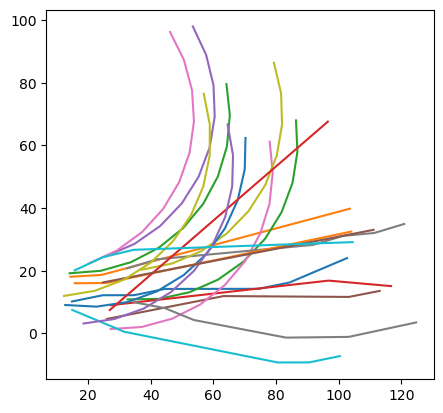

In [28]:
key = jax.random.PRNGKey(5) 

data = run_NN(key, N, 10, target_params)

plot_trajectory(data[0], data[1])
